<a href="https://colab.research.google.com/github/RizkyFirdiansyah/PCVK_Ganjil2026/blob/main/Week07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

In [ ]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    ax = plt.subplot(1, len(images), i+1)
    if len(img.shape) == 2:
      plt.imshow(img, cmap='gray')
    else:
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

    for spine in ax.spines.values():
      spine.set_visible(True)
      spine.set_color('black')
      spine.set_linewidth(0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title)
  plt.show()

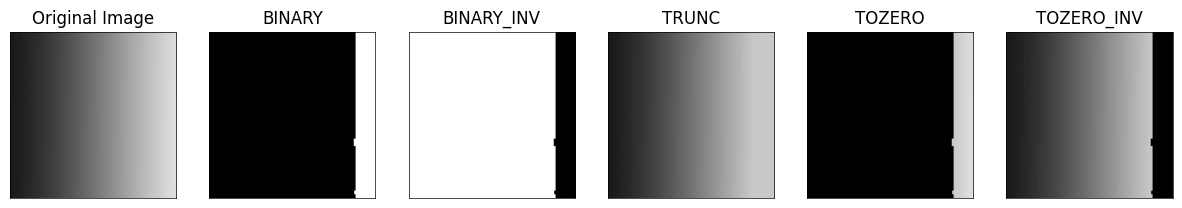

In [ ]:
# Global Threshold (binary, binary inverse, trunc, tozero, tozero inverse)
img = cv.imread('/content/drive/MyDrive/PCVK2026/gradient.jpg')
thresh = 200
maxval = 255

# Implementasi Manual
binary = np.where(img > thresh, maxval, 0).astype(np.uint8)
binary_inv = np.where(img <= thresh, maxval, 0).astype(np.uint8)
trunc = np.where(img > thresh, thresh, img).astype(np.uint8)
tozero = np.where(img > thresh, img, 0).astype(np.uint8)
tozero_inv = np.where(img <= thresh, img, 0).astype(np.uint8)

# Plotting
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, binary, binary_inv, trunc, tozero, tozero_inv]
show_side_by_side(images, titles)

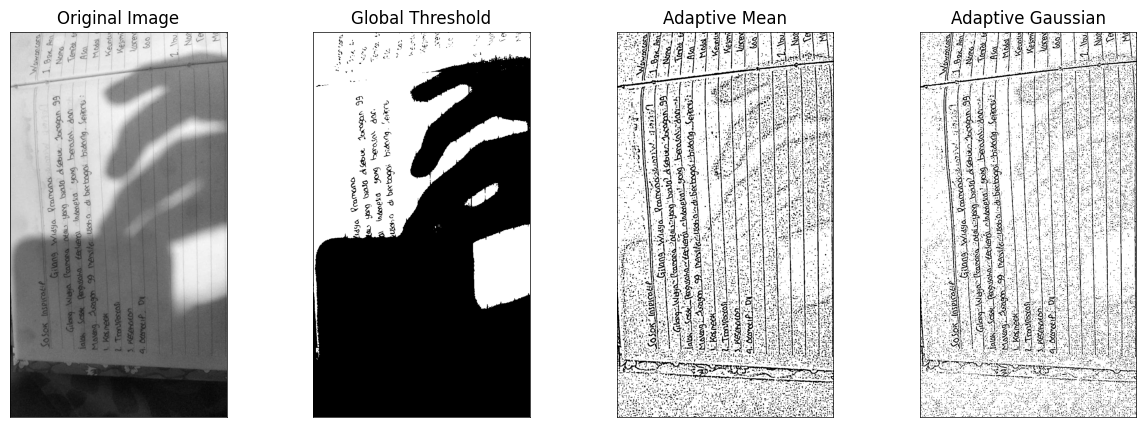

In [ ]:
# Addaptive Threshold (global threshold, adaptive mean, adaptive gaussian)
# Membuat kernel gaussian 2D secara manual
def get_gaussian_kernel(size, sigma):
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
    return kernel / np.sum(kernel)

def adaptive_threshold_manual(image, window_size=11, C=2, method='mean', sigma=2):
    pad = window_size // 2
    # Padding
    padded_img = np.pad(image, pad, mode='reflect')
    out_img = np.zeros_like(image)

    if method == 'gaussian':
        kernel = get_gaussian_kernel(window_size, sigma)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Ambil tetangga sebesar 11x11
            window = padded_img[i:i+window_size, j:j+window_size]

            if method == 'mean':
                local_thresh = np.mean(window) - C
            else: # gaussian
                local_thresh = np.sum(window * kernel) - C

            out_img[i, j] = 255 if image[i, j] > local_thresh else 0

    return out_img

sudoku_img = cv.imread('/content/drive/MyDrive/PCVK2026/citraTidakMerata.jpeg', 0)
global_thresh = np.where(sudoku_img > 127, 255, 0).astype(np.uint8)
th_mean_manual = adaptive_threshold_manual(sudoku_img, 11, 2, 'mean')
th_gauss_manual = adaptive_threshold_manual(sudoku_img, 11, 2, 'gaussian', 2)

# Plotting
titles = ['Original Image', 'Global Threshold', 'Adaptive Mean', 'Adaptive Gaussian']
images = [sudoku_img, global_thresh, th_mean_manual, th_gauss_manual]
show_side_by_side(images, titles)

/tmp/ipykernel_2665/2323099364.py:22: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
/tmp/ipykernel_2665/2323099364.py:23: RuntimeWarning: invalid value encountered in divide
  muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)


Final Thresh : 64


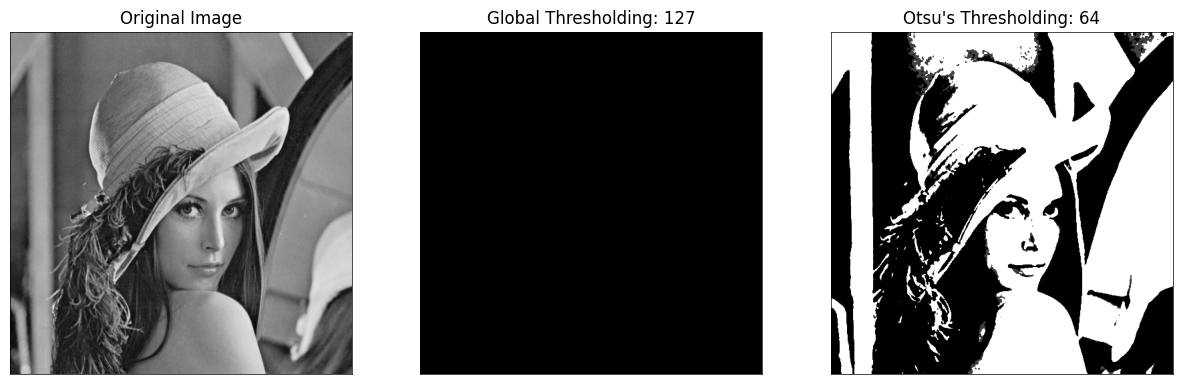

In [ ]:
# Otsu Thresholding Manual
from typing_extensions import final
img = cv.imread('/content/drive/MyDrive/PCVK2026/lenna-gc.jpg', 0)
low_contrast_img = cv.convertScaleAbs(img, alpha=0.3, beta=30) # menurunkan kontras citra
blur = cv.GaussianBlur(low_contrast_img, (5,5),0)
thresh = 127

def otsu(gray):
  pixel_number = gray.shape[0] * gray.shape[1]
  mean_weight = 1.0/pixel_number
  his, bins = np.histogram(gray, np.arange(0,257))
  final_thresh = -1
  final_value = -1
  intensity_arr = np.arange(256)
  for t in bins[1:-1]:
    pcb = np.sum(his[:t])
    pcf = np.sum(his[t:])
    Wb = pcb * mean_weight
    Wf = pcf * mean_weight

    mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
    muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)
    value = Wb * Wf * (mub - muf) ** 2

    if value > final_value:
      final_thresh = t
      final_value = value

  final_img = gray.copy()
  print(f'Final Thresh : ' + str(final_thresh))
  final_img[gray > final_thresh] = 255
  final_img[gray < final_thresh] = 0
  return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding: ") + str(otsu_thresh)
ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)
titles = ['Original Image', 'Global Thresholding: ' + str(thresh), x]
images = [low_contrast_img, th1, otsu_biner]
show_side_by_side(images, titles)

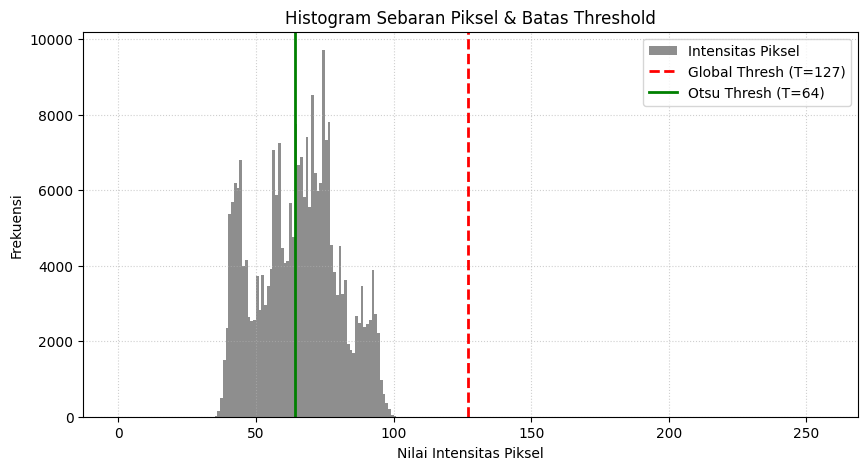

In [ ]:
# Menentukan nilai threshold yang digunakan sebelumnya
thresh_global = thresh
thresh_otsu = otsu_thresh

# Membuat plot histogram sebaran piksel
plt.figure(figsize=(10, 5))
plt.hist(low_contrast_img.ravel(), bins=256, range=[0, 256], color='dimgray', alpha=0.75, label='Intensitas Piksel')
plt.axvline(thresh_global, color='red', linestyle='--', linewidth=2, label=f'Global Thresh (T={thresh_global})')
plt.axvline(thresh_otsu, color='green', linestyle='-', linewidth=2, label=f'Otsu Thresh (T={thresh_otsu})')

plt.title('Histogram Sebaran Piksel & Batas Threshold')
plt.xlabel('Nilai Intensitas Piksel')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

/tmp/ipykernel_2665/3018378429.py:21: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
/tmp/ipykernel_2665/3018378429.py:22: RuntimeWarning: invalid value encountered in divide
  muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)


Final Thresh : 64


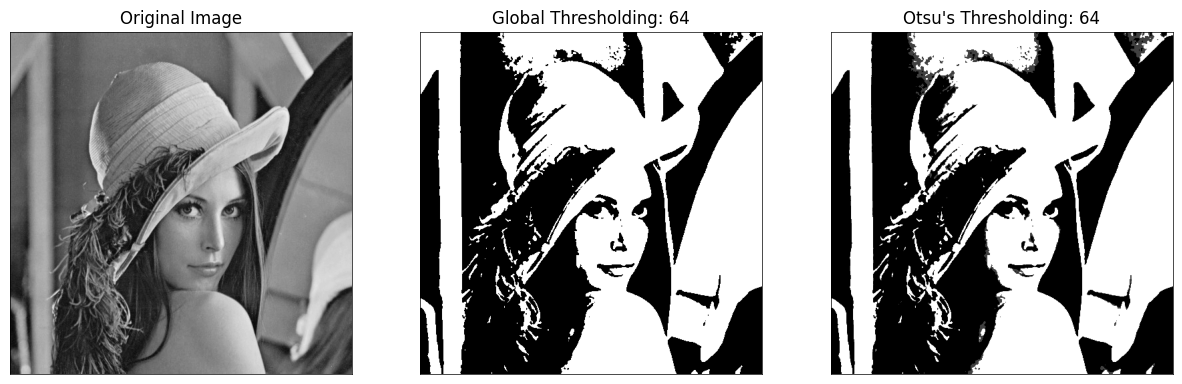

In [ ]:
# Otsu Thresholding Manual
from typing_extensions import final
img = cv.imread('/content/drive/MyDrive/PCVK2026/lenna-gc.jpg', 0)
low_contrast_img = cv.convertScaleAbs(img, alpha=0.3, beta=30) # menurunkan kontras citra
blur = cv.GaussianBlur(low_contrast_img, (5,5),0)
thresh = 64 # ubah dengan nilai ambang batas 64 (agar citra tetap terlihat)

def otsu(gray):
  pixel_number = gray.shape[0] * gray.shape[1]
  mean_weight = 1.0/pixel_number
  his, bins = np.histogram(gray, np.arange(0,257))
  final_thresh = -1
  final_value = -1
  intensity_arr = np.arange(256)
  for t in bins[1:-1]:
    pcb = np.sum(his[:t])
    pcf = np.sum(his[t:])
    Wb = pcb * mean_weight
    Wf = pcf * mean_weight

    mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
    muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)
    value = Wb * Wf * (mub - muf) ** 2

    if value > final_value:
      final_thresh = t
      final_value = value

  final_img = gray.copy()
  print(f'Final Thresh : ' + str(final_thresh))
  final_img[gray > final_thresh] = 255
  final_img[gray < final_thresh] = 0
  return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding: ") + str(otsu_thresh)
ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)
titles = ['Original Image', 'Global Thresholding: ' + str(thresh), x]
images = [low_contrast_img, th1, otsu_biner]
show_side_by_side(images, titles)

/tmp/ipykernel_2665/504036696.py:20: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)


Final Thresh : 166


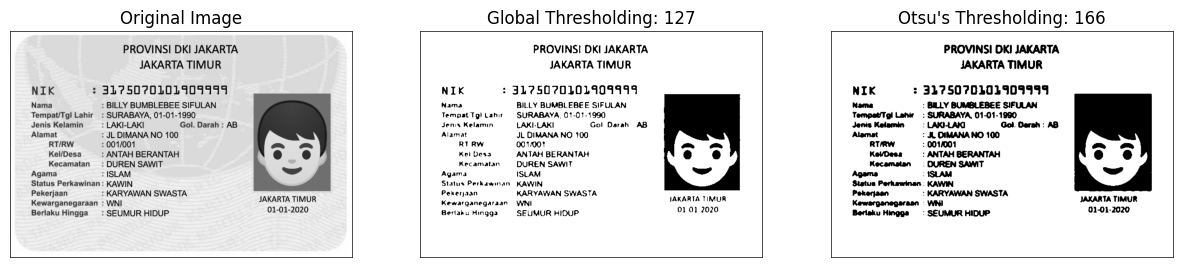

In [ ]:
# Otsu Thresholding Manual
from typing_extensions import final
img = cv.imread('/content/drive/MyDrive/PCVK2026/ktp_fulan.jpg', 0)
blur = cv.GaussianBlur(img, (5,5),0)
thresh = 127

def otsu(gray):
  pixel_number = gray.shape[0] * gray.shape[1]
  mean_weight = 1.0/pixel_number
  his, bins = np.histogram(gray, np.arange(0,257))
  final_thresh = -1
  final_value = -1
  intensity_arr = np.arange(256)
  for t in bins[1:-1]:
    pcb = np.sum(his[:t])
    pcf = np.sum(his[t:])
    Wb = pcb * mean_weight
    Wf = pcf * mean_weight

    mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
    muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)
    value = Wb * Wf * (mub - muf) ** 2

    if value > final_value:
      final_thresh = t
      final_value = value

  final_img = gray.copy()
  print(f'Final Thresh : ' + str(final_thresh))
  final_img[gray > final_thresh] = 255
  final_img[gray < final_thresh] = 0
  return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding: ") + str(otsu_thresh)
ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)
titles = ['Original Image', 'Global Thresholding: ' + str(thresh), x]
images = [img, th1, otsu_biner]
show_side_by_side(images, titles)

*** Seed (baris, kolom): (36, 43) | intensitas: 152


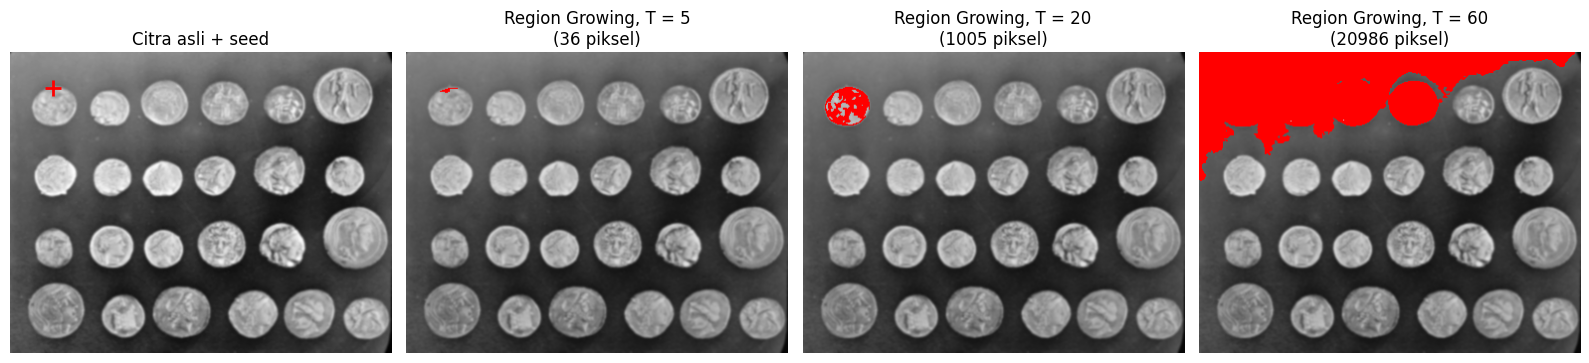



*** Seed (baris, kolom): (121, 63) | intensitas: 221


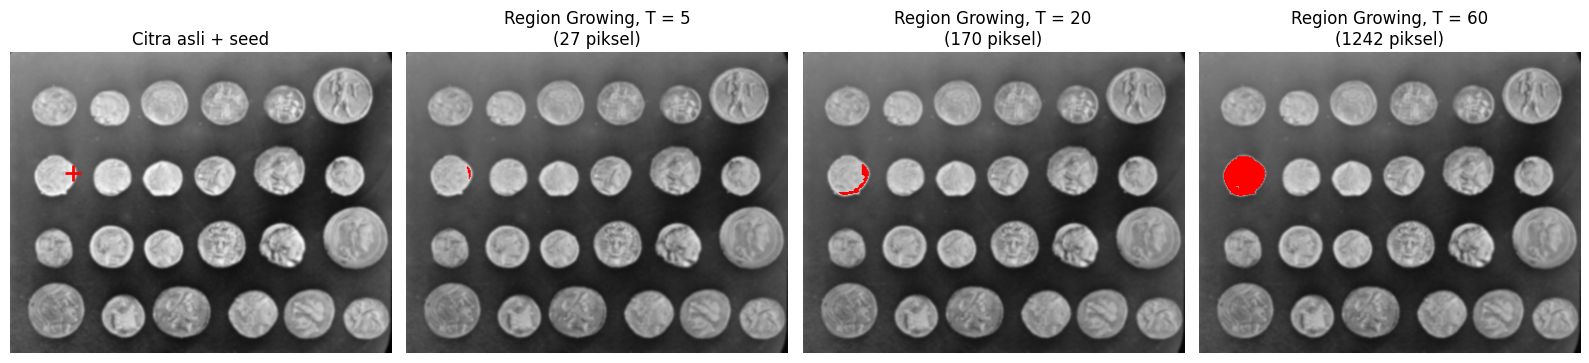



*** Seed (baris, kolom): (10, 10) | intensitas: 127


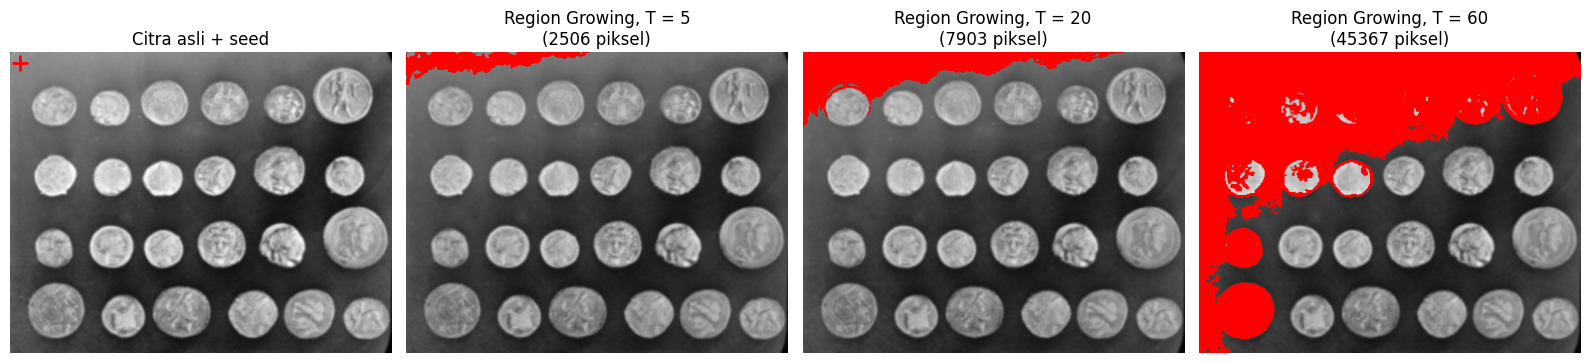

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from skimage import data
from skimage.filters import gaussian
from collections import deque

coins = data.coins()
coins = gaussian(coins, sigma=1, preserve_range=True).astype(np.uint8)  # Konversi ke uint8 untuk menghindari error CV_64F

# Fungsi Region Growing Manual (Queue/BFS)
def region_growing_manual(img, seed, T):
    height, width = img.shape
    segmented = np.zeros((height, width), dtype=bool)
    visited = np.zeros((height, width), dtype=bool)

    seed_row, seed_col = seed
    seed_val = float(img[seed_row, seed_col])

    queue = deque([(seed_row, seed_col)])
    visited[seed_row, seed_col] = True
    segmented[seed_row, seed_col] = True

    # Tetangga 4-konektivitas (atas, bawah, kiri, kanan)
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue:
        r, c = queue.popleft()

        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width:
                if not visited[nr, nc]:
                    visited[nr, nc] = True
                    # Kriteria kesamaan: selisih intensitas terhadap piksel seed <= T
                    if abs(float(img[nr, nc]) - seed_val) <= T:
                        segmented[nr, nc] = True
                        queue.append((nr, nc))

    return segmented

# 3 Seed Point (Tepi Koin, Dalam Koin, Latar)
seeds = [
    (36, 43),    # Seed 1: Tepi Koin
    (121, 63),   # Seed 2: Dalam Koin
    (10, 10)     # Seed 3: Latar (Background)
]

tolerances = [5, 20, 60]

# Tampilkan Hasil per Seed (4 Kolom per Baris)
for seed in seeds:
    seed_val = coins[seed[0], seed[1]]
    print(f"*** Seed (baris, kolom): {seed} | intensitas: {seed_val}")

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Kolom 1: Citra Asli + Penanda Seed (+)
    axes[0].imshow(coins, cmap='gray')
    axes[0].plot(seed[1], seed[0], 'r+', markersize=12, markeredgewidth=2)
    axes[0].set_title('Citra asli + seed')
    axes[0].axis('off')

    # Kolom 2-4: Hasil Region Growing Manual untuk T = 5, 20, 60
    for idx, T in enumerate(tolerances):
        mask = region_growing_manual(coins, seed, T)
        pixel_count = np.sum(mask)

        # Overlay warna merah pada wilayah tersegmentasi
        img_overlay = cv.cvtColor(coins, cv.COLOR_GRAY2RGB)
        img_overlay[mask] = [255, 0, 0]

        axes[idx + 1].imshow(img_overlay)
        axes[idx + 1].set_title(f'Region Growing, T = {T}\n({pixel_count} piksel)')
        axes[idx + 1].axis('off')

    plt.tight_layout()
    plt.show()
    print("\n")

*** Seed (baris, kolom): (121, 63) | intensitas: 224


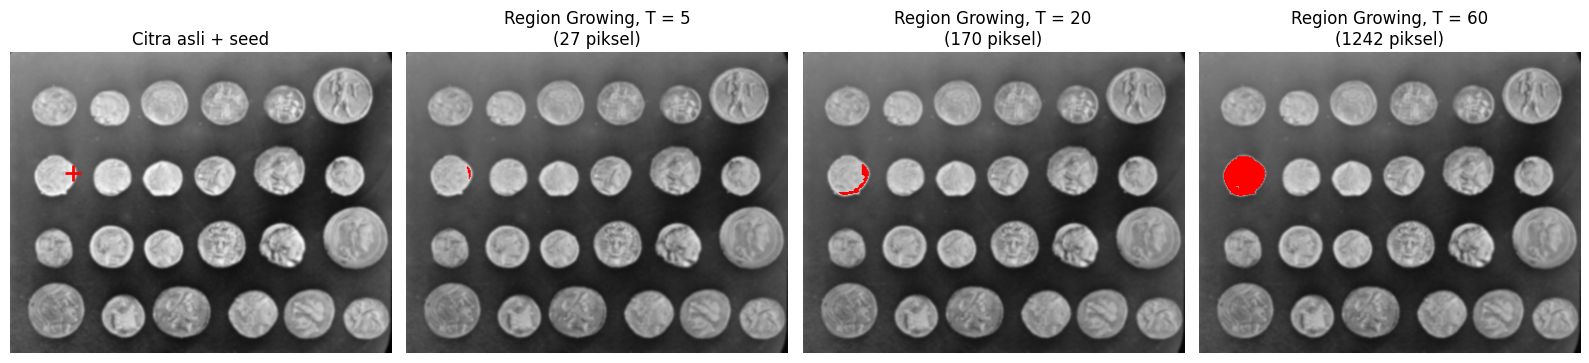

In [ ]:
from skimage.segmentation import flood
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from skimage import data

gray = data.coins()
seed = (121, 63)
seed_val = gray[seed[0], seed[1]]

region = flood(gray, seed_point=seed, tolerance=20, connectivity=1)
print(f"*** Seed (baris, kolom): {seed} | intensitas: {seed_val}")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Kolom 1: Citra Asli + Penanda Seed (+)
axes[0].imshow(coins, cmap='gray')
axes[0].plot(seed[1], seed[0], 'r+', markersize=12, markeredgewidth=2)
axes[0].set_title('Citra asli + seed')
axes[0].axis('off')

# Kolom 2-4: Hasil Region Growing Manual untuk T = 5, 20, 60
for idx, T in enumerate(tolerances):
    mask = region_growing_manual(coins, seed, T)
    pixel_count = np.sum(mask)

    # Overlay warna merah pada wilayah tersegmentasi
    img_overlay = cv.cvtColor(coins, cv.COLOR_GRAY2RGB)
    img_overlay[mask] = [255, 0, 0]

    axes[idx + 1].imshow(img_overlay)
    axes[idx + 1].set_title(f'Region Growing, T = {T}\n({pixel_count} piksel)')
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()
print("\n")

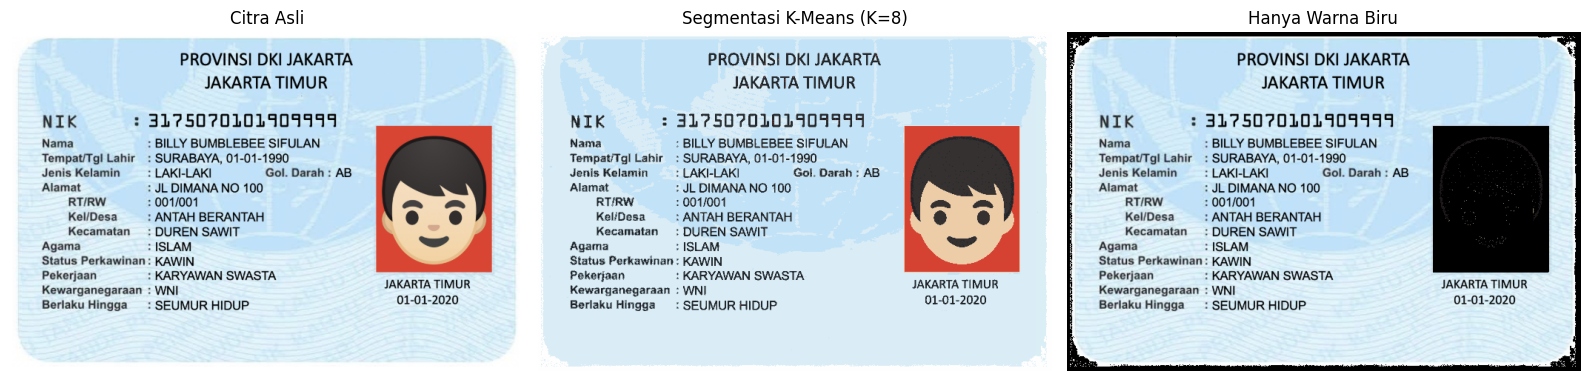

In [ ]:
# Segmentasi Warna Biru Latar KTP menggunakan K-Means dan seleksi rentang HSV
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Baca citra KTP
filename = '/content/drive/MyDrive/PCVK2026/ktp_fulan.jpg'
img_bgr = cv.imread(filename)

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

# 2. Reshape citra HSV menjadi array 2D
hsv_pixels = img_hsv.reshape((-1, 3)).astype(np.float32)

# 3. K-Means dengan K = 8
k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(hsv_pixels)

# Rekonstruksi citra HSV dari nilai centroid
centers = np.uint8(kmeans.cluster_centers_)
segmented_hsv = centers[labels].reshape(img_hsv.shape)
segmented_rgb = cv.cvtColor(segmented_hsv, cv.COLOR_HSV2RGB)

# 4. Ambil channel H, S, V dari hasil K-Means untuk filter warna biru
H = segmented_hsv[:, :, 0]
S = segmented_hsv[:, :, 1]
V = segmented_hsv[:, :, 2]

# Buat mask rentang warna biru sesuai petunjuk
mask_biru = np.where((H >= 85) & (H <= 130) & (S >= 25) & (V >= 40), 255, 0).astype(np.uint8)

# 5. Aplikasikan mask ke citra RGB asli
hanya_biru = cv.bitwise_and(img_rgb, img_rgb, mask=mask_biru)

# 6. Visualisasi
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_rgb)
plt.title(f'Segmentasi K-Means (K={k})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hanya_biru)
plt.title('Hanya Warna Biru')
plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
!apt-get -qq update
!apt-get -qq install tesseract-ocr tesseract-ocr-ind
!pip -q install pytesseract

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-ind.
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-ind_1%3a4.1.0-2_all.deb ...
Unpacking tesseract-ocr-ind (1:4.1.0-2) ...
Setting up tesseract-ocr-ind (1:4.1.0-2) ...


=== VISUALISASI HASIL SEGMENTASI TEROPTIMASI (V2) ===


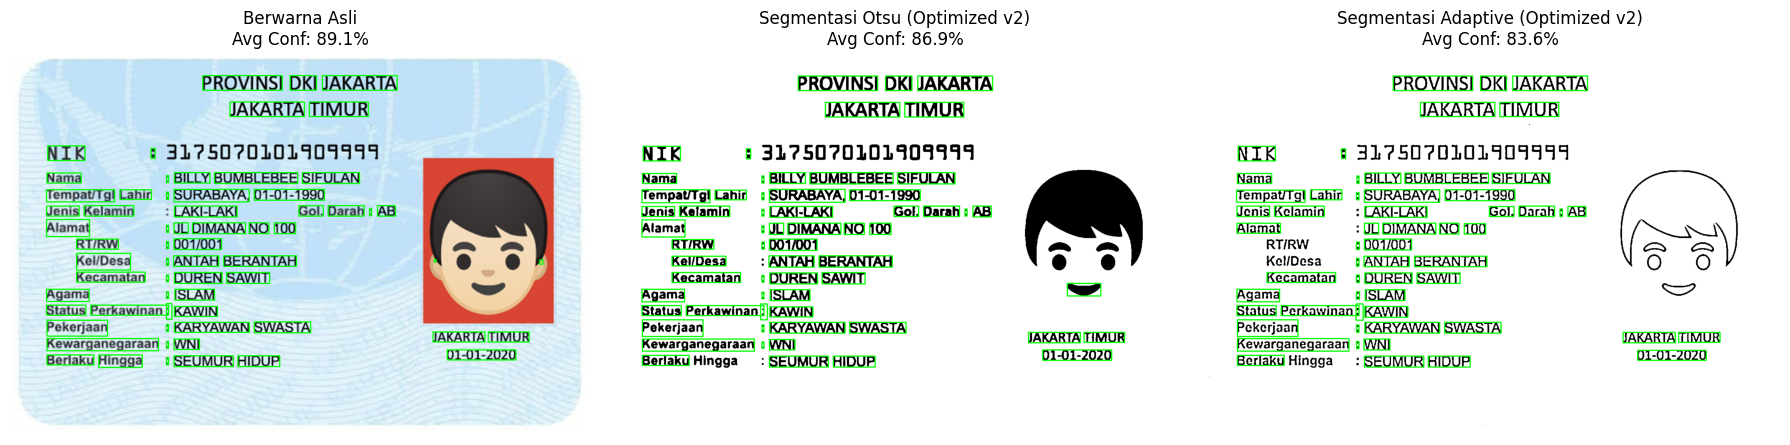


=== HASIL EKSTRAKSI TEKS (OCR) ===
========== HASIL OCR (BERWARNA ASLI) ==========
Rata-rata Confidence: 89.13%
--------------------------------------------------
PROVINSI DKI JAKARTA
JAKARTA TIMUR

NIK : 31?50?01014041419
Nama : BILLY BUMBLEBEE SIFULAN
Tempat/Tgl Lahir : SURABAYA, 01-01-1990
Jenis Kelamin : LAKI-LAKI Gol. Darah : AB
Alamat : JL DIMANA NO 100

RT/RW : 001/001

Kel/Desa : ANTAH BERANTAH t /

Kecamatan : DUREN SAWIT
Agama : ISLAM
Status Perkawinan : KAWIN
Pekerjaan : KARYAWAN SWASTA
Kewarganegaraan : WNI JAKARTA TIMUR
Berlaku Hingga — : SEUMUR HIDUP 01-01-2020

========== HASIL OCR (SEGMENTASI OTSU (OPTIMIZED V2)) ==========
Rata-rata Confidence: 86.91%
--------------------------------------------------
PROVINSI DKI JAKARTA
JAKARTA TIMUR
NIK : 317?5070101409111
Nama : BILLY BUMBLEBEE SIFULAN
Tempat/Tg! Lahir : SURABAYA, 01-01-1990
Jenis Kelamin 1 LAKI-LAKI Gol. Darah : AB
Atamat : JL DIMANA NO 100
RT/RW : 001/001 . Aa
KellDesa —: ANTAH BERANTAH
Kecamatan : DUREN SAWIT
A

In [15]:
# Perbandingan Pembacaan Teks pada Citra Berwarna dan Hasil Segmentasi
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
from pytesseract import Output

# 1. Muat citra KTP dari Drive
filename = '/content/drive/MyDrive/PCVK2026/ktp_fulan.jpg'
img_bgr = cv.imread(filename)

# 2. Rescale (2x) untuk memperjelas resolusi karakter
img_resized = cv.resize(img_bgr, None, fx=2, fy=2, interpolation=cv.INTER_CUBIC)
img_rgb = cv.cvtColor(img_resized, cv.COLOR_BGR2RGB)

# 3. Gunakan Channel Red (BGR index 2) untuk mengeliminasi background biru KTP
red_channel = img_resized[:, :, 2]

# 4. Smoothing Terarah
blur_otsu = cv.GaussianBlur(red_channel, (5, 5), 0)    # Mengurangi noise halus untuk Otsu
blur_adaptive = cv.medianBlur(red_channel, 3)          # Mengurangi noise impulsif untuk Adaptive

# 5. Segmentasi Otsu Teroptimasi
_, otsu_raw = cv.threshold(blur_otsu, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
kernel_close = cv.getStructuringElement(cv.MORPH_RECT, (2, 2))
citra_otsu_opt = cv.morphologyEx(otsu_raw, cv.MORPH_CLOSE, kernel_close)

# 6. Segmentasi Adaptive Teroptimasi
# Menggunakan blockSize=15 dan C=15 untuk mengisolasi teks dari latar secara maksimal
citra_adaptive_raw = cv.adaptiveThreshold(
    blur_adaptive, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 15, 15
)
kernel_open = cv.getStructuringElement(cv.MORPH_RECT, (2, 2))
citra_adaptive_opt = cv.morphologyEx(citra_adaptive_raw, cv.MORPH_OPEN, kernel_open)

# Daftar Citra untuk diuji
daftar_citra_v2 = {
    'Berwarna Asli': img_rgb,
    'Segmentasi Otsu (Optimized v2)': cv.cvtColor(citra_otsu_opt, cv.COLOR_GRAY2RGB),
    'Segmentasi Adaptive (Optimized v2)': cv.cvtColor(citra_adaptive_opt, cv.COLOR_GRAY2RGB)
}

# 7. Eksekusi Tesseract OCR dan Kalkulasi Nilai Confidence
config_ocr = '--psm 6 -l ind'
visualisasi_hasil_v2 = {}
ocr_results_v2 = {}

for nama, img_input in daftar_citra_v2.items():
    # Dapatkan data bounding box & confidence
    data = pytesseract.image_to_data(img_input, config=config_ocr, output_type=Output.DICT)
    img_bbox = img_input.copy()

    n_boxes = len(data['text'])
    conf_valid = []

    for i in range(n_boxes):
        conf = int(data['conf'][i])
        text_strip = data['text'][i].strip()

        if conf > 0 and text_strip != '':
            conf_valid.append(conf)
            if conf > 60:
                (x, y, w, h) = (data['left'][i], data['top'][i], data['width'][i], data['height'][i])
                cv.rectangle(img_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2)

    avg_conf = np.mean(conf_valid) if conf_valid else 0
    visualisasi_hasil_v2[nama] = (img_bbox, avg_conf)

    # Ambil teks mentah hasil OCR
    teks_hasil = pytesseract.image_to_string(img_input, config=config_ocr)
    ocr_results_v2[nama] = (teks_hasil, avg_conf)

# 8. Plot Hasil Segmentasi Terlebih Dahulu
print("=== VISUALISASI HASIL SEGMENTASI TEROPTIMASI (V2) ===")
plt.figure(figsize=(18, 6))
idx = 1
for nama, (img_bbox, avg_conf) in visualisasi_hasil_v2.items():
    plt.subplot(1, 3, idx)
    plt.imshow(img_bbox)
    plt.title(f"{nama}\nAvg Conf: {avg_conf:.1f}%")
    plt.axis('off')
    idx += 1
plt.tight_layout()
plt.show()

# 9. Tampilkan Teks Hasil Ekstraksi OCR
print("\n=== HASIL EKSTRAKSI TEKS (OCR) ===")
for nama, (teks, avg_conf) in ocr_results_v2.items():
    print(f"========== HASIL OCR ({nama.upper()}) ==========")
    print(f"Rata-rata Confidence: {avg_conf:.2f}%")
    print("-" * 50)
    print(teks.strip())
    print("=" * 50 + "\n")